# DISTRIBUTION DU POIDS

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [ ]:
data = pd.read_excel("data.xlsx")
df = data.copy()

Distribution avec toutes les données 
(Donc moins de données en V3 et V5)

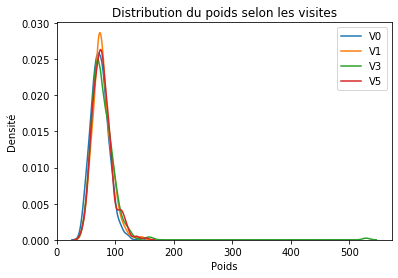

Pic de POIDS_V0 : 70.57
Pic de POIDS_V1 : 73.65
Pic de POIDS_V3 : 71.61
Pic de POIDS_V5 : 74.59


In [46]:
#Courbe
plt.figure()

sns.kdeplot(df["POIDS_V0"], label="V0")
sns.kdeplot(df["POIDS_V1"], label="V1")
sns.kdeplot(df["POIDS_V3"], label="V3")
sns.kdeplot(df["POIDS_V5"], label="V5")

plt.xlabel("Poids")
plt.ylabel("Densité")
plt.title("Distribution du poids selon les visites")
plt.legend()

plt.show()


#Pic de poids
cols = ["POIDS_V0", "POIDS_V1", "POIDS_V3", "POIDS_V5"]

for col in cols:
    data = df[col].dropna()
    
    kde = gaussian_kde(data)
    
    x_vals = np.linspace(data.min(), data.max(), 1000)
    y_vals = kde(x_vals)
    
    peak_x = x_vals[np.argmax(y_vals)]
    
    print(f"Pic de {col} : {peak_x:.2f}")

On veut maintenant comparer un même groupe donc seulement les patients ayant un poids renseigné pour toutes les visites

In [47]:
cols = ["POIDS_V0", "POIDS_V1", "POIDS_V3", "POIDS_V5"]
df_clean = df.dropna(subset=cols)

print("Nombre de patients ayant le poids renseigné pour toutes les visites :", df_clean.shape[0])

Nombre de patients ayant le poids renseigné pour toutes les visites : 171


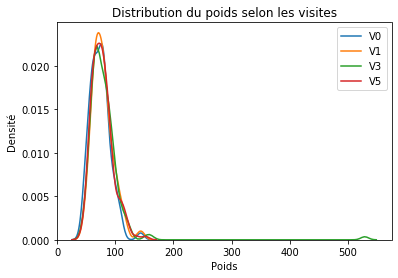

Pic de POIDS_V0 : 75.66
Pic de POIDS_V1 : 71.19
Pic de POIDS_V3 : 73.54
Pic de POIDS_V5 : 72.00


In [48]:
plt.figure()

sns.kdeplot(df_clean["POIDS_V0"], label="V0")
sns.kdeplot(df_clean["POIDS_V1"], label="V1")
sns.kdeplot(df_clean["POIDS_V3"], label="V3")
sns.kdeplot(df_clean["POIDS_V5"], label="V5")

plt.xlabel("Poids")
plt.ylabel("Densité")
plt.title("Distribution du poids selon les visites")
plt.legend()

plt.show()


#Pic de poids
cols = ["POIDS_V0", "POIDS_V1", "POIDS_V3", "POIDS_V5"]

for col in cols:
    data = df_clean[col].dropna()
    
    kde = gaussian_kde(data)
    
    x_vals = np.linspace(data.min(), data.max(), 1000)
    y_vals = kde(x_vals)
    
    peak_x = x_vals[np.argmax(y_vals)]
    
    print(f"Pic de {col} : {peak_x:.2f}")

Le poids ne semble pas augmenter

Mais on observe un petit pic pour les personnes de plus de 120kg

In [29]:
#On observe seulement les patients faisant plus de 120kg à la V0
df_clean_120 = df_clean[df_clean["POIDS_V0"] >= 120]

print("Nombre de patients de plus de 120kg ayant le poids renseigné pour toutes les visites :", df_clean_120.shape[0])

Nombre de patients de plus de 120kg ayant le poids renseigné pour toutes les visites : 2


--> Trop peu de patients pour que l'information soit exploitable

Mais on peut se demander :

# Combien de patient ont pris du poids ?

Entre V0 et V1

In [56]:
nb_pris = (df_clean["POIDS_V1"] > df_clean["POIDS_V0"]).sum()

print("Nombre de patients ayant pris du poids entre V0 et V1 :", nb_pris)

Nombre de patients ayant pris du poids entre V0 et V1 : 130


Donc 130 patients sur 171 ont pris du poids entre V0 et V1. 

--> La distribution ne se déplace par vers la droite en V1 mais les patients prennent du poids entre V0 et V1.

###### Les variations individuelles peuvent être de faible amplitude et/ou asymétriques, avec des gains et des pertes de poids qui se compensent partiellement à l’échelle de la population.

#### On va observer la distribution des changements :

In [50]:
df_clean["delta"] = df_clean["POIDS_V1"] - df_clean["POIDS_V0"]

c:\Users\etudiant\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


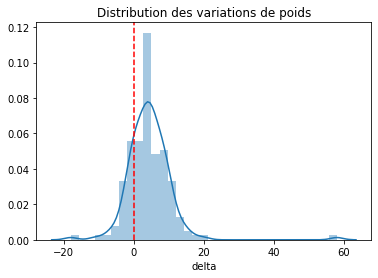

Centre de la distribution des variations de poids : 4.356725146198831


In [51]:
sns.distplot(df_clean["delta"], kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution des variations de poids")
plt.show()


centre = df_clean["delta"].mean()
print("Centre de la distribution des variations de poids :", centre)

Les patients ont pris en moyenne 4.36kg entre V0 et V1

## Avec tous les patients ayant le poids renseignés pour V0 et V1 :

On recalcule la nouvelle base avec les patients ayant le poids renseignés pour V0 et V1 sans prendre en compte V3 et V5 :

In [54]:
cols = ["POIDS_V0", "POIDS_V1"]
df_clean_V01 = df.dropna(subset=cols)

print("Nombre de patients ayant le poids renseigné pour V0 et V1 :", df_clean_V01.shape[0])

Nombre de patients ayant le poids renseigné pour V0 et V1 : 504


In [55]:
nb_pris = (df_clean_V01["POIDS_V1"] > df_clean_V01["POIDS_V0"]).sum()

print("Nombre de patients ayant pris du poids entre V0 et V1 :", nb_pris)

Nombre de patients ayant pris du poids entre V0 et V1 : 362


c:\Users\etudiant\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


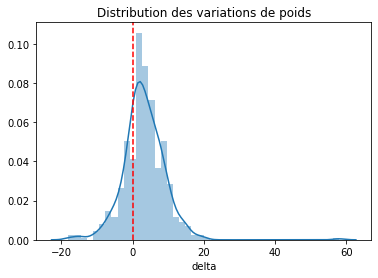

Centre de la distribution des variations de poids : 3.2083333333333335


In [57]:
df_clean_V01["delta"] = df_clean_V01["POIDS_V1"] - df_clean_V01["POIDS_V0"]


sns.distplot(df_clean_V01["delta"], kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution des variations de poids")
plt.show()


centre = df_clean_V01["delta"].mean()
print("Centre de la distribution des variations de poids :", centre)

# CONCLUSION

### - Les patients de la base de données PrediStim ont pris en moyenne 3.2kg entre V0 et V1 -